In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import scanpy as sc
import matplotlib.pyplot as plt
from itertools import product

np.set_printoptions(suppress=True)

%reload_ext autoreload
%autoreload 2

In [2]:
klein = sc.read_h5ad('../../datasets/Mouse_Hematopoiesis/klein_paga.h5ad')
klein

AnnData object with n_obs × n_vars = 126861 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
from scipy.io import mmread
from scipy.sparse import csr_matrix, save_npz, load_npz

clones = load_npz('../../datasets/Mouse_Hematopoiesis/clone_meta.npz')
clones

<130887x5864 sparse matrix of type '<class 'numpy.int64'>'
	with 49302 stored elements in Compressed Sparse Row format>

<Axes: >

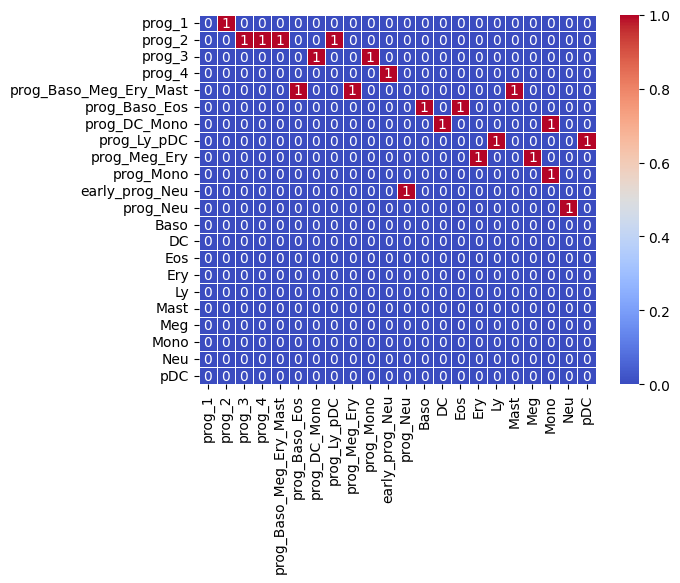

In [4]:
paga = pd.read_csv('paga_transitions.csv', index_col=0)
sns.heatmap(paga, annot=True, linewidth=.5, cmap='coolwarm')
# plt.savefig('./figures/transmap.svg', dpi=300, bbox_inches='tight', transparent=True)

### Pre-processing and filtering

In [5]:
klein.obs['Time_point'] = klein.obs['Time_point'].astype('category')

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_anndata.py:843: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


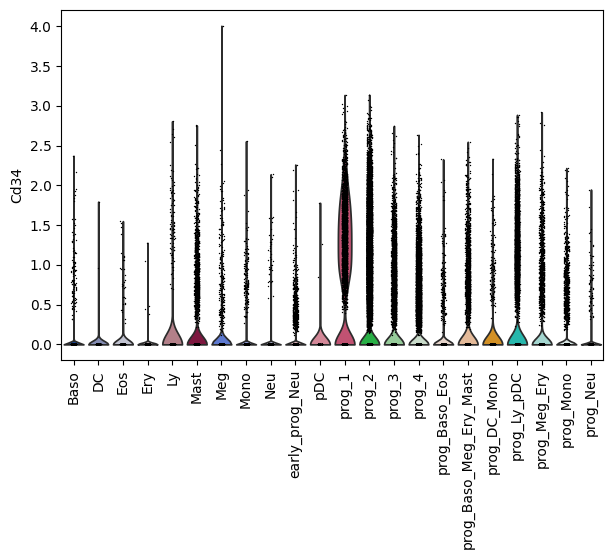

In [13]:
sc.pl.violin(klein, groupby='label_man', keys=['Cd34'], rotation=90)

In [6]:
clones_used = clones.todense()[np.array([int(item) for item in klein.obs.index])]
clones_used.shape

(126861, 5864)

In [7]:
index, ids = np.where(clones_used != 0)
clones_label = []

for idx in range(klein.shape[0]):
    clones_label.append(f'Clone_{ids[np.where(index == idx)[0][0]]}' if idx in index else 'Clone_nan')

In [8]:
klein.obs['clones'] = clones_label
klein.obs

,Time_point,Population,Annotation,Well,time_cat,leiden,comb,label_man,clones
0,6.0,LK,undiff,2,6.0,16,undiff_16,prog_2,Clone_573
1,6.0,LK,undiff,2,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast,Clone_1440
2,6.0,LK,Monocyte,2,6.0,3,Monocyte_3,prog_Mono,Clone_394
3,6.0,LK,Neutrophil,2,6.0,12,Neutrophil_12,early_prog_Neu,Clone_nan
4,6.0,LK,undiff,2,6.0,9,undiff_9,prog_Meg_Ery,Clone_1972
...,...,...,...,...,...,...,...,...,...
130882,6.0,LSK,undiff,1,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast,Clone_nan
130883,6.0,LSK,undiff,1,6.0,0,undiff_0,prog_2,Clone_1374
130884,6.0,LSK,Monocyte,1,6.0,2,Monocyte_2,Mono,Clone_nan
130885,6.0,LSK,Monocyte,1,6.0,2,Monocyte_2,Mono,Clone_nan


In [9]:
np.unique(klein.obs['clones'].values).shape

(5860,)

In [10]:
adata_clone = klein.obs[klein.obs['clones'] != 'Clone_nan']
adata_clone['pop_time'] = adata_clone['label_man'].astype(str) + '_' + adata_clone['Time_point'].astype(str)
adata_clone = adata_clone.drop(labels=['time_cat', 'leiden', 'comb'], axis=1)
adata_clone

/tmp/ipykernel_733209/2184172387.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_clone['pop_time'] = adata_clone['label_man'].astype(str) + '_' + adata_clone['Time_point'].astype(str)


,Time_point,Population,Annotation,Well,label_man,clones,pop_time
0,6.0,LK,undiff,2,prog_2,Clone_573,prog_2_6.0
1,6.0,LK,undiff,2,prog_Baso_Meg_Ery_Mast,Clone_1440,prog_Baso_Meg_Ery_Mast_6.0
2,6.0,LK,Monocyte,2,prog_Mono,Clone_394,prog_Mono_6.0
4,6.0,LK,undiff,2,prog_Meg_Ery,Clone_1972,prog_Meg_Ery_6.0
6,6.0,LK,Neutrophil,2,prog_Neu,Clone_1450,prog_Neu_6.0
...,...,...,...,...,...,...,...
130875,6.0,LSK,undiff,1,prog_Meg_Ery,Clone_12,prog_Meg_Ery_6.0
130876,6.0,LSK,undiff,1,prog_2,Clone_267,prog_2_6.0
130877,6.0,LSK,Neutrophil,1,early_prog_Neu,Clone_3534,early_prog_Neu_6.0
130879,6.0,LSK,Monocyte,1,prog_Mono,Clone_4945,prog_Mono_6.0


### From DNA barcodes to meta-clones

In [11]:
df = adata_clone.groupby(by=['pop_time', 'clones']).size().reset_index(name='counts')
df = df.sort_values(by=['pop_time'])
df

,pop_time,clones,counts
0,Baso_2.0,Clone_5443,2
1,Baso_2.0,Clone_582,1
171,Baso_4.0,Clone_4473,6
172,Baso_4.0,Clone_4543,10
173,Baso_4.0,Clone_4548,1
...,...,...,...
17176,prog_Neu_6.0,Clone_2694,1
17175,prog_Neu_6.0,Clone_2693,1
17174,prog_Neu_6.0,Clone_2689,2
17172,prog_Neu_6.0,Clone_2671,5


In [12]:
df = df.pivot(index='clones', columns='pop_time', values='counts')
df.index.name = None
df.columns.name = None
df = df.fillna(0.0)
df

,Baso_2.0,Baso_4.0,Baso_6.0,DC_2.0,DC_4.0,DC_6.0,Eos_4.0,Eos_6.0,Ery_2.0,Ery_4.0,...,prog_Ly_pDC_6.0,prog_Meg_Ery_2.0,prog_Meg_Ery_4.0,prog_Meg_Ery_6.0,prog_Mono_2.0,prog_Mono_4.0,prog_Mono_6.0,prog_Neu_2.0,prog_Neu_4.0,prog_Neu_6.0
Clone_0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Clone_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0
Clone_10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Clone_100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Clone_1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Clone_995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0
Clone_996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,0.0,4.0
Clone_997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0
Clone_998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,3.0,22.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
klein.obs['Time_point'] = klein.obs['Time_point'].astype(str)

for time in ['2.0', '4.0', '6.0']:
    print (df[[i for i in df.columns if i.endswith(time)]].sum().sum())
    print (klein.obs[klein.obs['Time_point'].values == time].shape)

4558.0
(27757, 9)
14679.0
(47444, 9)
28742.0
(51660, 9)


In [14]:
mat = sc.AnnData(df, dtype=np.float32)
df.columns = mat.var.index
mat

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 5859 × 64

In [15]:
sc.pp.filter_cells(mat, min_counts=3)
sc.pp.filter_genes(mat, min_counts=1)
mat

AnnData object with n_obs × n_vars = 4214 × 62
    obs: 'n_counts'
    var: 'n_counts'

In [16]:
mat.X.sum().sum()

44756.0

In [17]:
sc.tl.pca(mat)
sc.pp.neighbors(mat, n_neighbors=10, n_pcs=50)
sc.tl.umap(mat)

In [18]:
sc.set_figure_params(dpi_save=600, format='svg', figsize=(6, 5))
sc.tl.leiden(mat, resolution=0.25)
# sc.pl.scatter(mat, basis='umap', color='leiden', legend_loc='right margin', size=75,
#     title='', frameon=False, palette=sns.color_palette('tab20'))

In [19]:
sc.set_figure_params(dpi_save=600, format='svg', figsize=(6, 5))
sc.tl.rank_genes_groups(mat, 'leiden', method='wilcoxon')
# sc.pl.rank_genes_groups(mat, n_genes=25, sharey=False, ncols=3)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


### UMAP related plots

In [20]:
adata_clone = klein[klein.obs['clones'] != 'Clone_nan', :]
adata_clone = adata_clone[adata_clone.obs['clones'].isin(mat.obs.index), :]
adata_clone

View of AnnData object with n_obs × n_vars = 44756 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

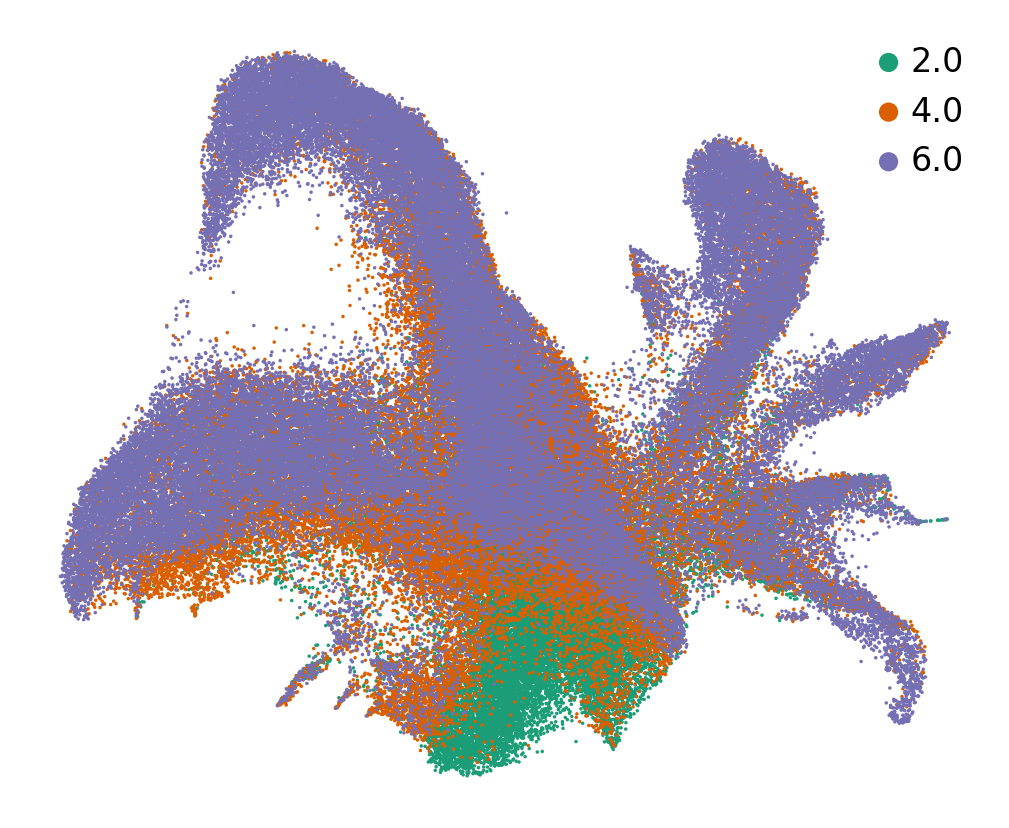

In [20]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(7, 6), transparent=True)
sc.pl.scatter(klein, basis='umap', color='Time_point', 
              legend_loc='best', palette=sns.color_palette('Dark2'), 
              save='timepoints.svg', size=10, frameon=False, title='',
              legend_fontsize=15)

In [21]:
leiden = []
for clone in adata_clone.obs['clones'].values:
    leiden.append(mat.obs.loc[clone]['leiden'])
adata_clone.obs['meta_clones'] = leiden

/tmp/ipykernel_733209/520276951.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_clone.obs['meta_clones'] = leiden


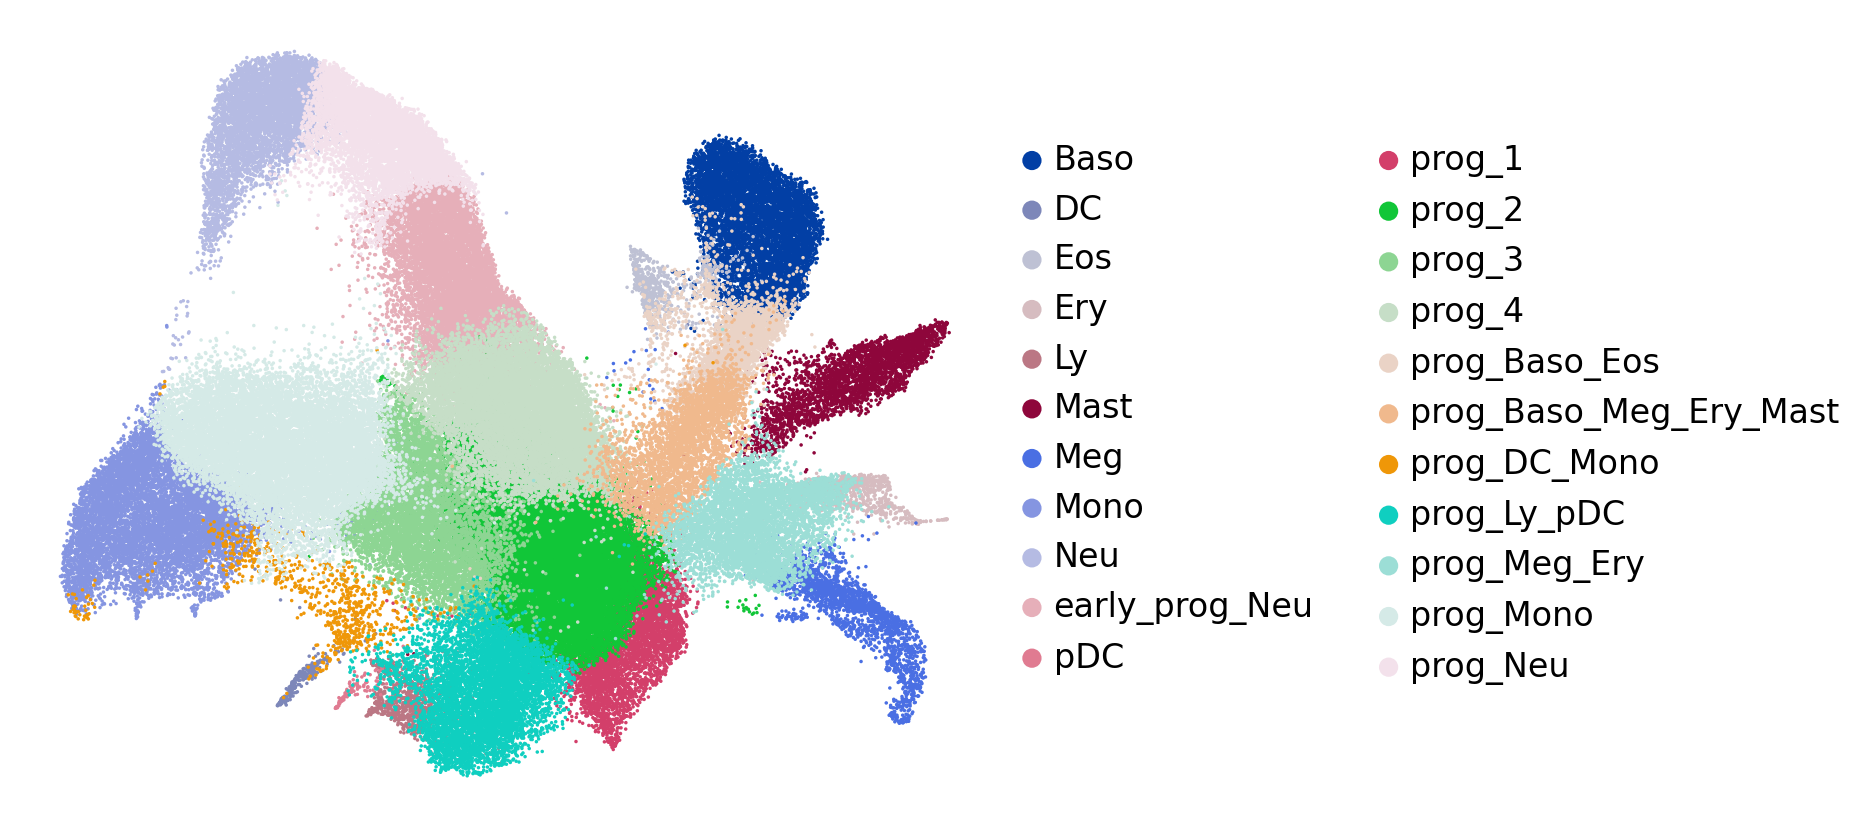

In [22]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(7, 6), transparent=True)
sc.pl.scatter(klein, basis='umap', color='label_man', 
              legend_loc='right margin', 
              save='populations.svg', size=10, frameon=False, 
              title='', legend_fontsize=15)

In [22]:
klein.obs['Meta clones'] = np.zeros(klein.shape[0]) - 1
for i in list(adata_clone.obs.index):
    klein.obs.at[i, 'Meta clones'] = adata_clone.obs.loc[i]['meta_clones']
klein.obs['Meta clones'] = [str(i) for i in klein.obs['Meta clones']]

/tmp/ipykernel_733209/1922454633.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  klein.obs.at[i, 'Meta clones'] = adata_clone.obs.loc[i]['meta_clones']


In [23]:
group_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
klein.obs['group'] = pd.Categorical(klein.obs['Meta clones'], categories=group_labels)

In [49]:
klein.write('./klein_update.h5ad')

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


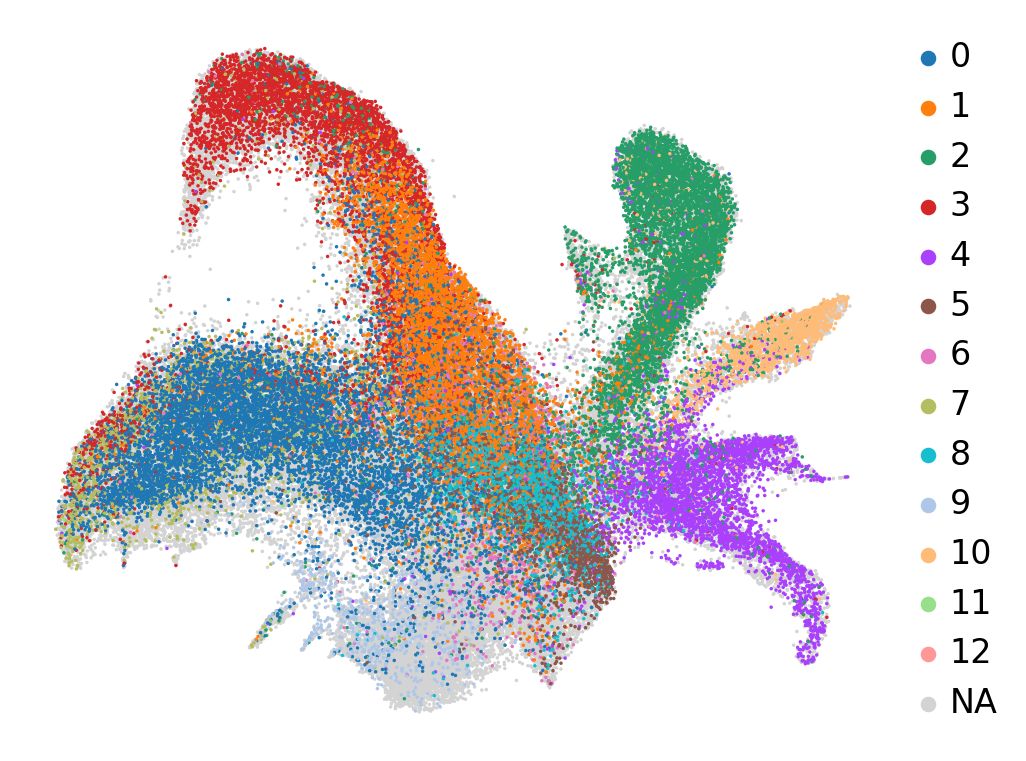

In [25]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(7, 6), transparent=True)
sc.pl.umap(klein, groups=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12'], color=['group'],
            size=10, frameon=False, title='', legend_fontsize=15, save='metaclones')

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


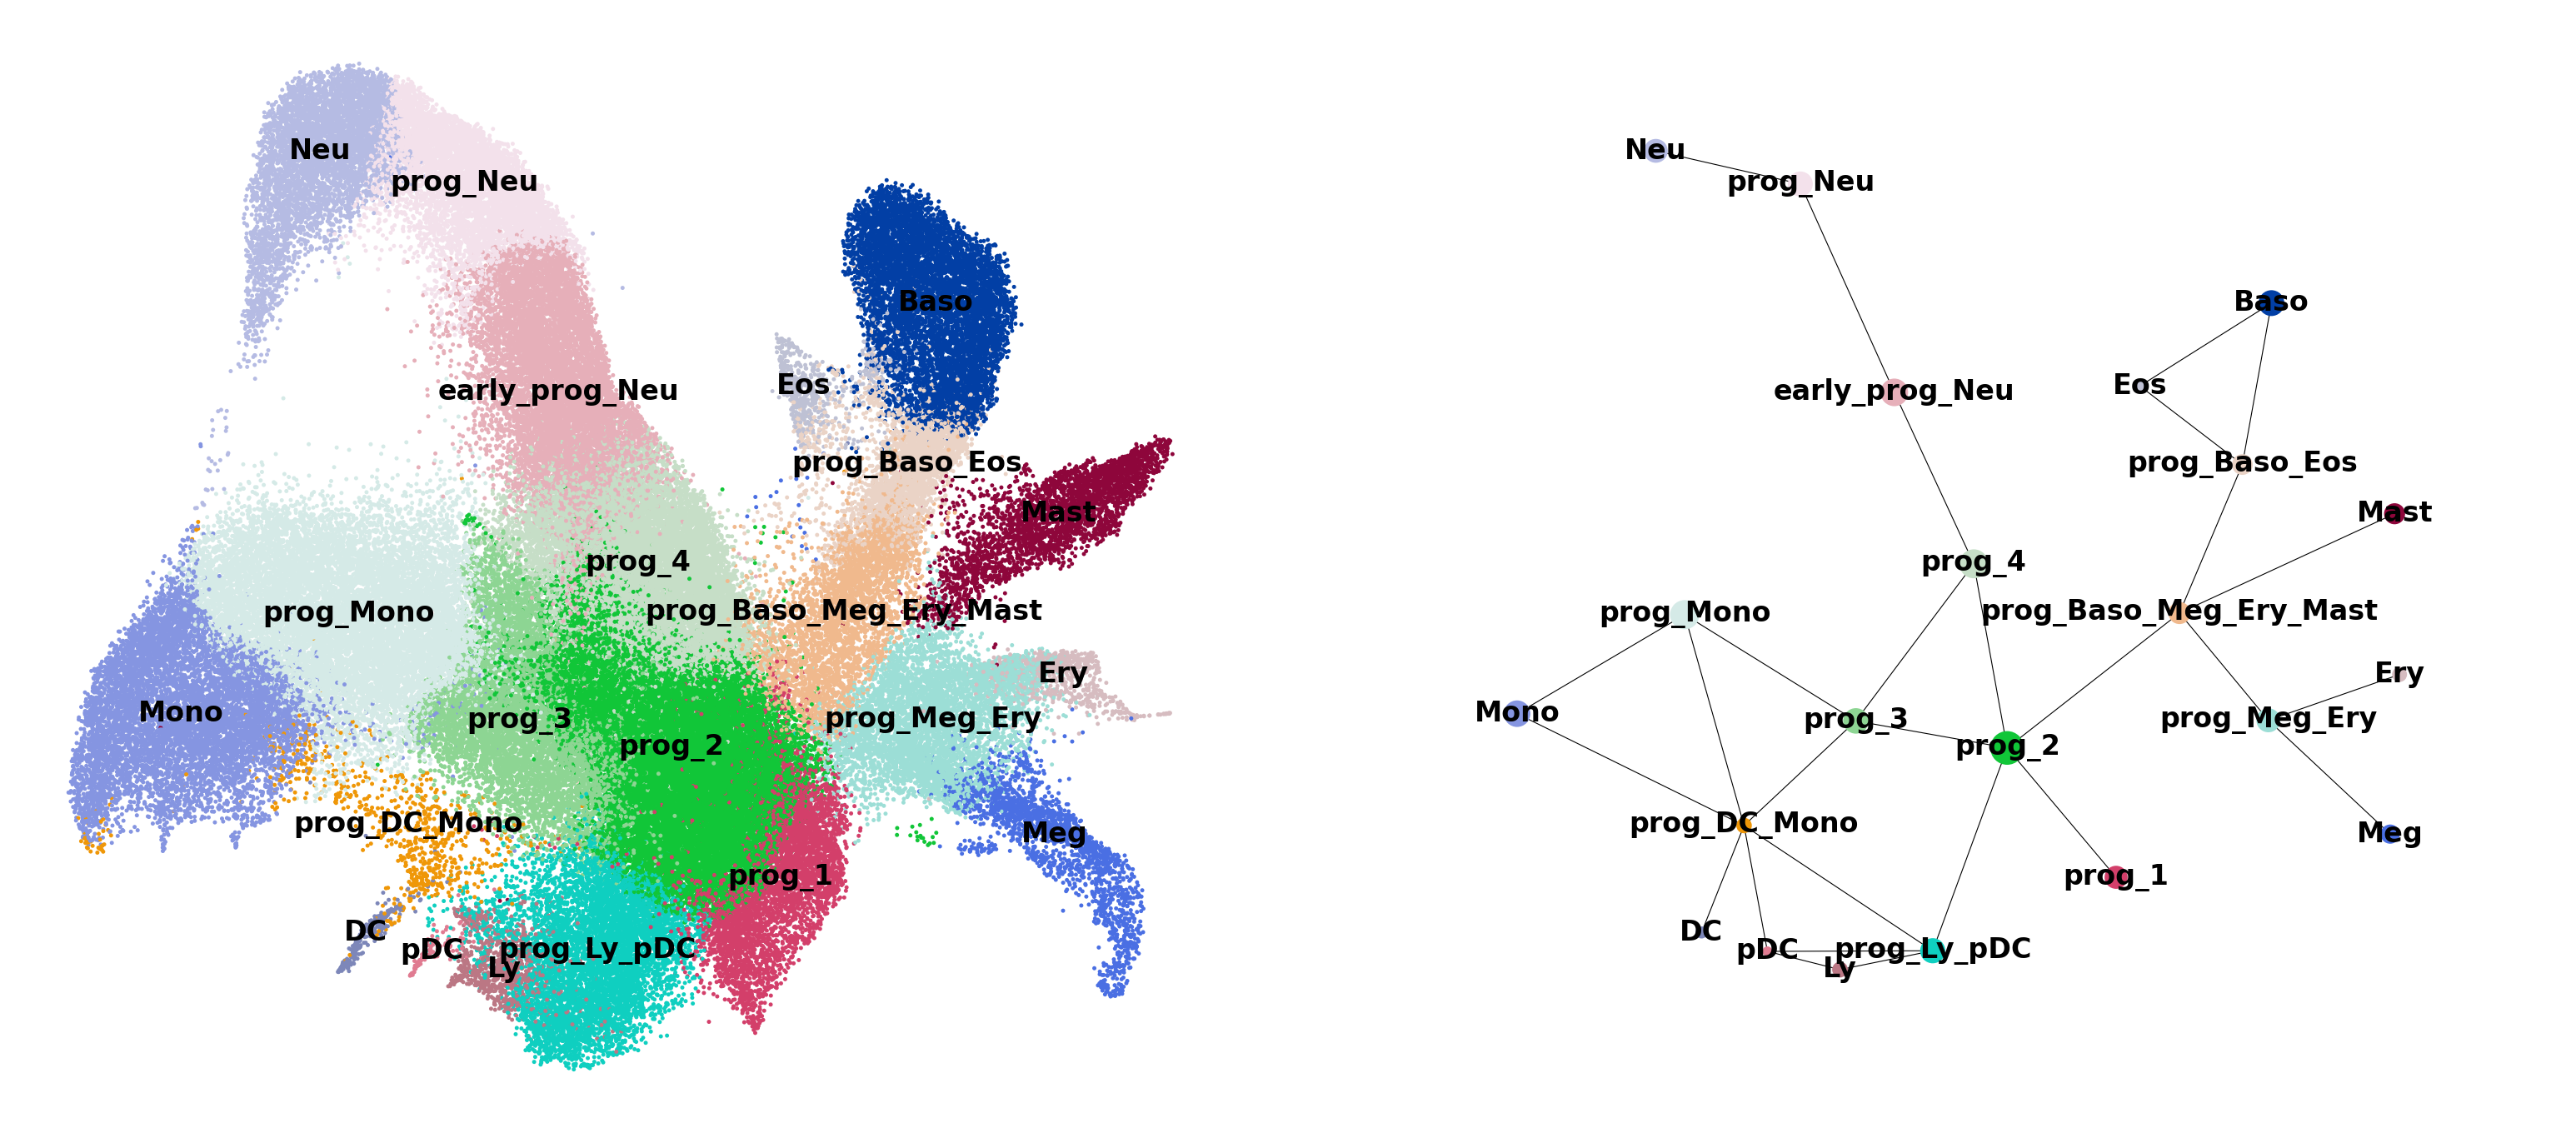

In [32]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(10, 10), transparent=True)
sc.pl.paga_compare(
    klein, basis='umap', threshold=0.25,
    save='_supp.svg', size=20, frameon=False, 
    title='', legend_fontsize=15, edge_width_scale=0.5, max_edge_width=0.5
    # labels=['' for i in range(len(set(klein.obs['label_man'])))]
)

In [ ]:
adata_clone.write('./adata_used.h5ad')

In [ ]:
sc.set_figure_params(dpi_save=600, format='svg', figsize=(7, 6))
hsc = adata_clone[adata_clone.obs['label_man'] == 'prog_1']
sc.pl.scatter(hsc, basis='umap', color=['meta_clones'],
              legend_loc='best', size=50, frameon=False, title='', legend_fontsize=14)

### Generate CLADES inputs (from experimental data)

In [24]:
times = ['2.0', '4.0', '6.0']
num_meta_clones = len(set(mat.obs.leiden))
num_times = len(times)
num_pops = len(set(adata_clone.obs.label_man))
print (num_meta_clones, num_times, num_pops)

13 3 22


In [25]:
print (adata_clone[adata_clone.obs['Time_point'].values == '2.0', :].shape)
print (adata_clone[adata_clone.obs['Time_point'].values == '4.0', :].shape)
print (adata_clone[adata_clone.obs['Time_point'].values == '6.0', :].shape)

(3042, 5000)
(13804, 5000)
(27910, 5000)


In [32]:
from natsort import natsorted
meta_clones = list(set(mat.obs.leiden))
meta_clones = natsorted(meta_clones)
meta_clones

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']

In [27]:
scaling_factor = [1.0808, 3.1616, 8.7108]

In [28]:
pops = np.array(paga.columns)
pops

array(['prog_1', 'prog_2', 'prog_3', 'prog_4', 'prog_Baso_Meg_Ery_Mast',
       'prog_Baso_Eos', 'prog_DC_Mono', 'prog_Ly_pDC', 'prog_Meg_Ery',
       'prog_Mono', 'early_prog_Neu', 'prog_Neu', 'Baso', 'DC', 'Eos',
       'Ery', 'Ly', 'Mast', 'Meg', 'Mono', 'Neu', 'pDC'], dtype=object)

In [64]:
kinetics = np.zeros((num_meta_clones + 1, num_times, num_pops), dtype=np.float32)

for (idi, meta), (idj, time), (idk, pop) in product(enumerate(meta_clones), enumerate(times), enumerate(pops)):
    kinetics[idi, idj, idk] = int(adata_clone.obs[(adata_clone.obs['Time_point'] == time) & (adata_clone.obs['meta_clones'] == meta) & (adata_clone.obs['label_man'] == pop)].shape[0] * scaling_factor[idj])

In [65]:
kinetics.sum()

289858.0

In [66]:
for (idj, time), (idk, pop) in product(enumerate(times), enumerate(pops)):
        kinetics[-1, idj, idk] = int(klein.obs[(klein.obs['Time_point'] == time) & (klein.obs['label_man'] == pop)].shape[0] * scaling_factor[idj])

In [67]:
kinetics.sum()

919821.0

### Generate CLADES inputs (initial conditions)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


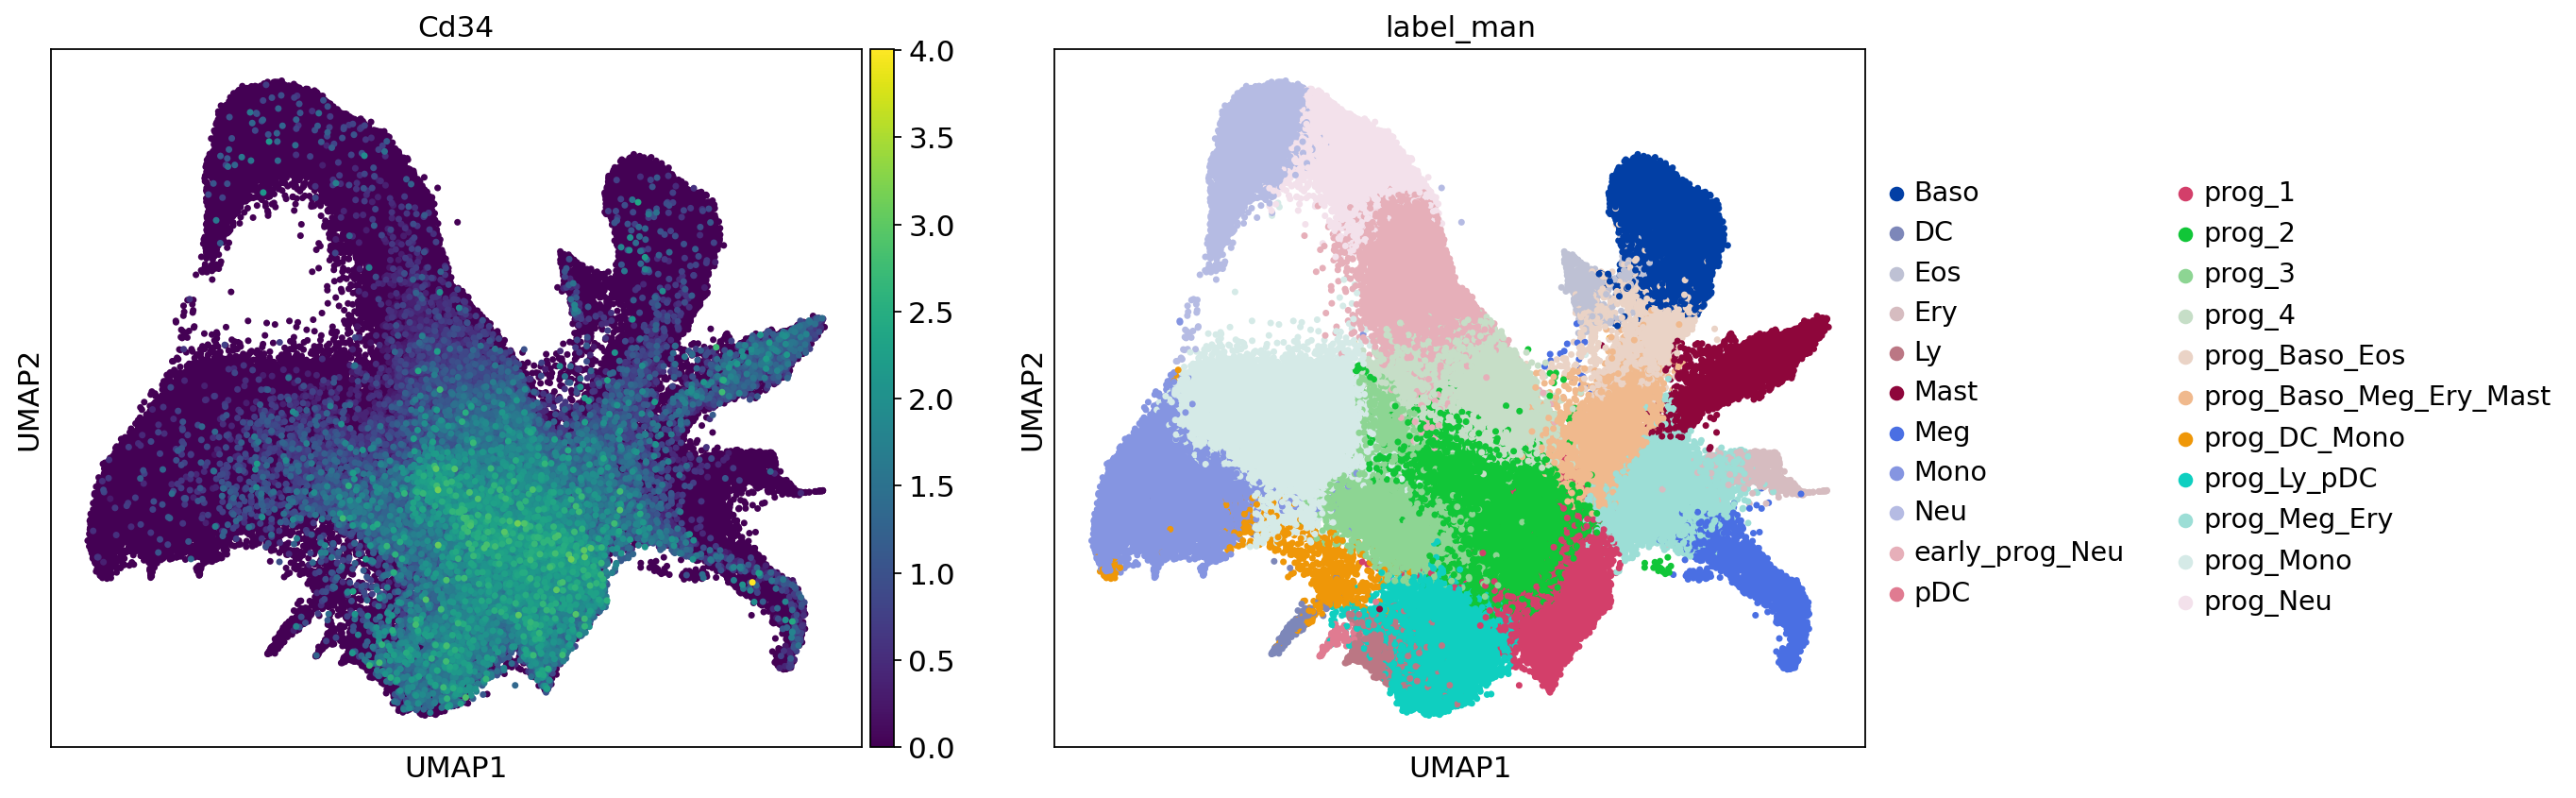

In [81]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(7, 6), transparent=True)
sc.pl.umap(klein, color=['Cd34', 'label_man'], s=40)

In [68]:
initial_label = [
    'prog_1','prog_2','prog_3','prog_4','prog_Meg_Ery',
    'prog_Baso_Meg_Ery_Mast','prog_Mono','early_prog_Neu',
    'prog_Neu','prog_Ly_pDC'
]

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


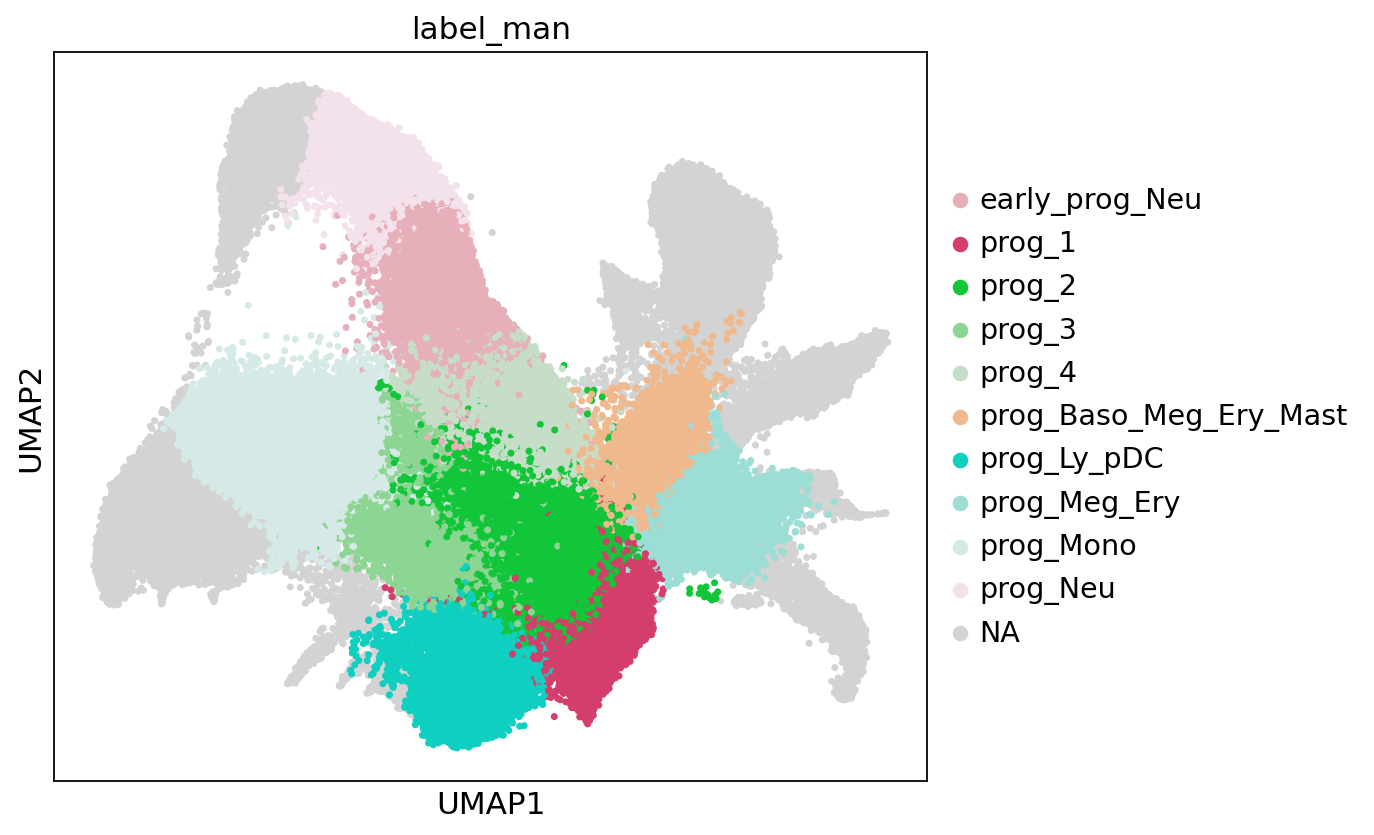

In [84]:
sc.set_figure_params(dpi_save=300, format='svg', figsize=(7, 6), transparent=True)
sc.pl.umap(klein, color=['label_man'], groups=initial_label, s=40)

In [69]:
df = pd.crosstab(adata_clone.obs.clones, adata_clone.obs.Time_point)
df

Time_point,2.0,4.0,6.0
clones,,,
Clone_0,0,2,3
Clone_1,0,13,7
Clone_10,1,3,10
Clone_1000,0,4,0
Clone_1001,2,1,0
...,...,...,...
Clone_995,0,4,13
Clone_996,1,12,20
Clone_997,0,3,7


In [70]:
vec = np.where(np.count_nonzero(df, 1) == 3)[0]
vec.shape

(941,)

In [71]:
df = df.iloc[vec].iloc[:].copy()
df

Time_point,2.0,4.0,6.0
clones,,,
Clone_10,1,3,10
Clone_1015,1,3,3
Clone_1029,3,5,16
Clone_1030,2,2,1
Clone_1036,1,3,3
...,...,...,...
Clone_982,1,22,27
Clone_991,1,4,6
Clone_992,1,1,4


In [72]:
vec = np.isin(adata_clone.obs.clones, df.index)
vec

array([False, False, False, ..., False, False, False])

In [73]:
adata_subset = adata_clone[vec].copy()
adata_subset

AnnData object with n_obs × n_vars = 13310 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'meta_clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [74]:
len(np.unique(adata_subset.obs['clones']))

941

In [75]:
adata_day2 = adata_subset[adata_subset.obs['Time_point'] == '2.0'].copy()
adata_day2

AnnData object with n_obs × n_vars = 1310 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'meta_clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [81]:
anno = pd.read_csv('./annotations.csv')
pops = anno['populations'].values
pops

array(['prog_1', 'prog_2', 'prog_3', 'prog_4', 'prog_Baso_Meg_Ery_Mast',
       'prog_Baso_Eos', 'prog_DC_Mono', 'prog_Ly_pDC', 'prog_Meg_Ery',
       'prog_Mono', 'early_prog_Neu', 'prog_Neu', 'Baso', 'DC', 'Eos',
       'Ery', 'Ly', 'Mast', 'Meg', 'Mono', 'Neu', 'pDC'], dtype=object)

In [82]:
init_con = pd.DataFrame(0, index=anno['clones'].values[:14], columns=pops)
init_con

,prog_1,prog_2,prog_3,prog_4,prog_Baso_Meg_Ery_Mast,prog_Baso_Eos,prog_DC_Mono,prog_Ly_pDC,prog_Meg_Ery,prog_Mono,...,Baso,DC,Eos,Ery,Ly,Mast,Meg,Mono,Neu,pDC
Clone 0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Clone 1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Clone 2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Clone 3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Clone 4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Clone 5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Clone 6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Clone 7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Clone 8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Clone 9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [83]:
df_init_pops = pd.DataFrame(columns=initial_label)
df_init_pops

,prog_1,prog_2,prog_3,prog_4,prog_Meg_Ery,prog_Baso_Meg_Ery_Mast,prog_Mono,early_prog_Neu,prog_Neu,prog_Ly_pDC


In [84]:
adata_day2.obs['meta_clones'] = adata_day2.obs['meta_clones'].astype('category')

In [85]:
for meta_clone in adata_day2.obs['meta_clones'].cat.categories:
    adata_day2_meta = adata_day2[adata_day2.obs['meta_clones'] == meta_clone].copy()

    df_temp = pd.crosstab(adata_day2_meta.obs.clones, adata_day2_meta.obs.label_man)
    df_temp = pd.concat([df_init_pops, df_temp], axis=0).fillna(0)
    df_temp = df_temp[initial_label]
    df_init = np.round(df_temp.sum() / df_temp.sum().sum() * mat.obs.leiden.value_counts()[meta_clone])
    
    for pop in initial_label:
        init_con.loc['Clone ' + meta_clone, pop] = df_init[pop]
        init_con.fillna(0, inplace=True)

/tmp/ipykernel_733209/1982086414.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp = pd.concat([df_init_pops, df_temp], axis=0).fillna(0)
/tmp/ipykernel_733209/1982086414.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp = pd.concat([df_init_pops, df_temp], axis=0).fillna(0)
/tmp/ipykernel_733209/1982086414.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option(

In [86]:
df_temp = pd.crosstab(adata_day2.obs.clones, adata_day2.obs.label_man)
df_temp = pd.concat([df_init_pops, df_temp], axis=0).fillna(0)
df_temp = df_temp[initial_label]
df_init = np.round(df_temp.sum() / df_temp.sum().sum() * 5859)

for pop in initial_label:
    init_con.loc['Clone BG', pop] = df_init[pop]
    init_con.fillna(0, inplace=True)

/tmp/ipykernel_733209/2174382679.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp = pd.concat([df_init_pops, df_temp], axis=0).fillna(0)


In [87]:
init_con

,prog_1,prog_2,prog_3,prog_4,prog_Baso_Meg_Ery_Mast,prog_Baso_Eos,prog_DC_Mono,prog_Ly_pDC,prog_Meg_Ery,prog_Mono,...,Baso,DC,Eos,Ery,Ly,Mast,Meg,Mono,Neu,pDC
Clone 0,90,380,6,0,0,0,0,199,6,0,...,0,0,0,0,0,0,0,0,0,0
Clone 1,218,325,6,26,0,0,0,29,3,3,...,0,0,0,0,0,0,0,0,0,0
Clone 2,59,200,8,6,183,0,0,14,56,0,...,0,0,0,0,0,0,0,0,0,0
Clone 3,5,400,13,76,5,0,0,0,8,0,...,0,0,0,0,0,0,0,0,0,0
Clone 4,53,77,6,0,0,0,0,15,258,0,...,0,0,0,0,0,0,0,0,0,0
Clone 5,202,97,7,0,7,0,0,45,7,7,...,0,0,0,0,0,0,0,0,0,0
Clone 6,79,176,8,0,0,0,0,26,0,0,...,0,0,0,0,0,0,0,0,0,0
Clone 7,6,159,59,11,0,0,0,42,0,0,...,0,0,0,0,0,0,0,0,0,0
Clone 8,137,43,0,0,0,0,0,14,0,0,...,0,0,0,0,0,0,0,0,0,0
Clone 9,8,25,0,0,4,0,0,140,0,0,...,0,0,0,0,0,0,0,0,0,0


In [95]:
init_con[df_init_pops.columns]

,prog_1,prog_2,prog_3,prog_4,prog_Meg_Ery,prog_Baso_Meg_Ery_Mast,prog_Mono,early_prog_Neu,prog_Neu,prog_Ly_pDC
Clone 0,90,380,6,0,6,0,0,0,0,199
Clone 1,218,325,6,26,3,0,3,0,0,29
Clone 2,59,200,8,6,56,183,0,0,0,14
Clone 3,5,400,13,76,8,5,0,0,0,0
Clone 4,53,77,6,0,258,0,0,0,0,15
Clone 5,202,97,7,0,7,7,7,0,0,45
Clone 6,79,176,8,0,0,0,0,0,0,26
Clone 7,6,159,59,11,0,0,0,6,0,42
Clone 8,137,43,0,0,0,0,0,0,0,14
Clone 9,8,25,0,0,0,4,0,0,0,140


In [88]:
mat.obs.leiden.value_counts()

leiden
0     682
1     610
2     527
3     506
4     409
5     374
6     289
7     282
8     195
9     178
10    112
11     35
12     15
Name: count, dtype: int64

In [89]:
np.sum(init_con, axis=1)

Clone 0      681
Clone 1      610
Clone 2      526
Clone 3      507
Clone 4      409
Clone 5      372
Clone 6      289
Clone 7      283
Clone 8      194
Clone 9      177
Clone 10     111
Clone 11       0
Clone 12       0
Clone BG    5858
dtype: int64

In [90]:
kinetics_with_init = np.zeros((num_meta_clones + 1, num_times + 1, num_pops), dtype=np.float32)
kinetics_with_init.shape

(14, 4, 22)

In [91]:
kinetics_with_init[:, 0, :] = init_con.values
kinetics_with_init[:, 1:, :] = kinetics

In [92]:
kinetics_with_init = kinetics_with_init[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 13], :, :]
kinetics_with_init.shape

(12, 4, 22)

In [93]:
kinetics_with_init.sum()

929555.0

In [148]:
np.savetxt('./kinetics_corrected.txt', np.reshape(kinetics_with_init, (12, (num_times + 1) * num_pops)), fmt='%.0f')

### Visualize total cell counts

In [150]:
kinetics_with_init = np.swapaxes(kinetics_with_init, 0, 1)
kinetics_with_init.shape

(4, 12, 22)

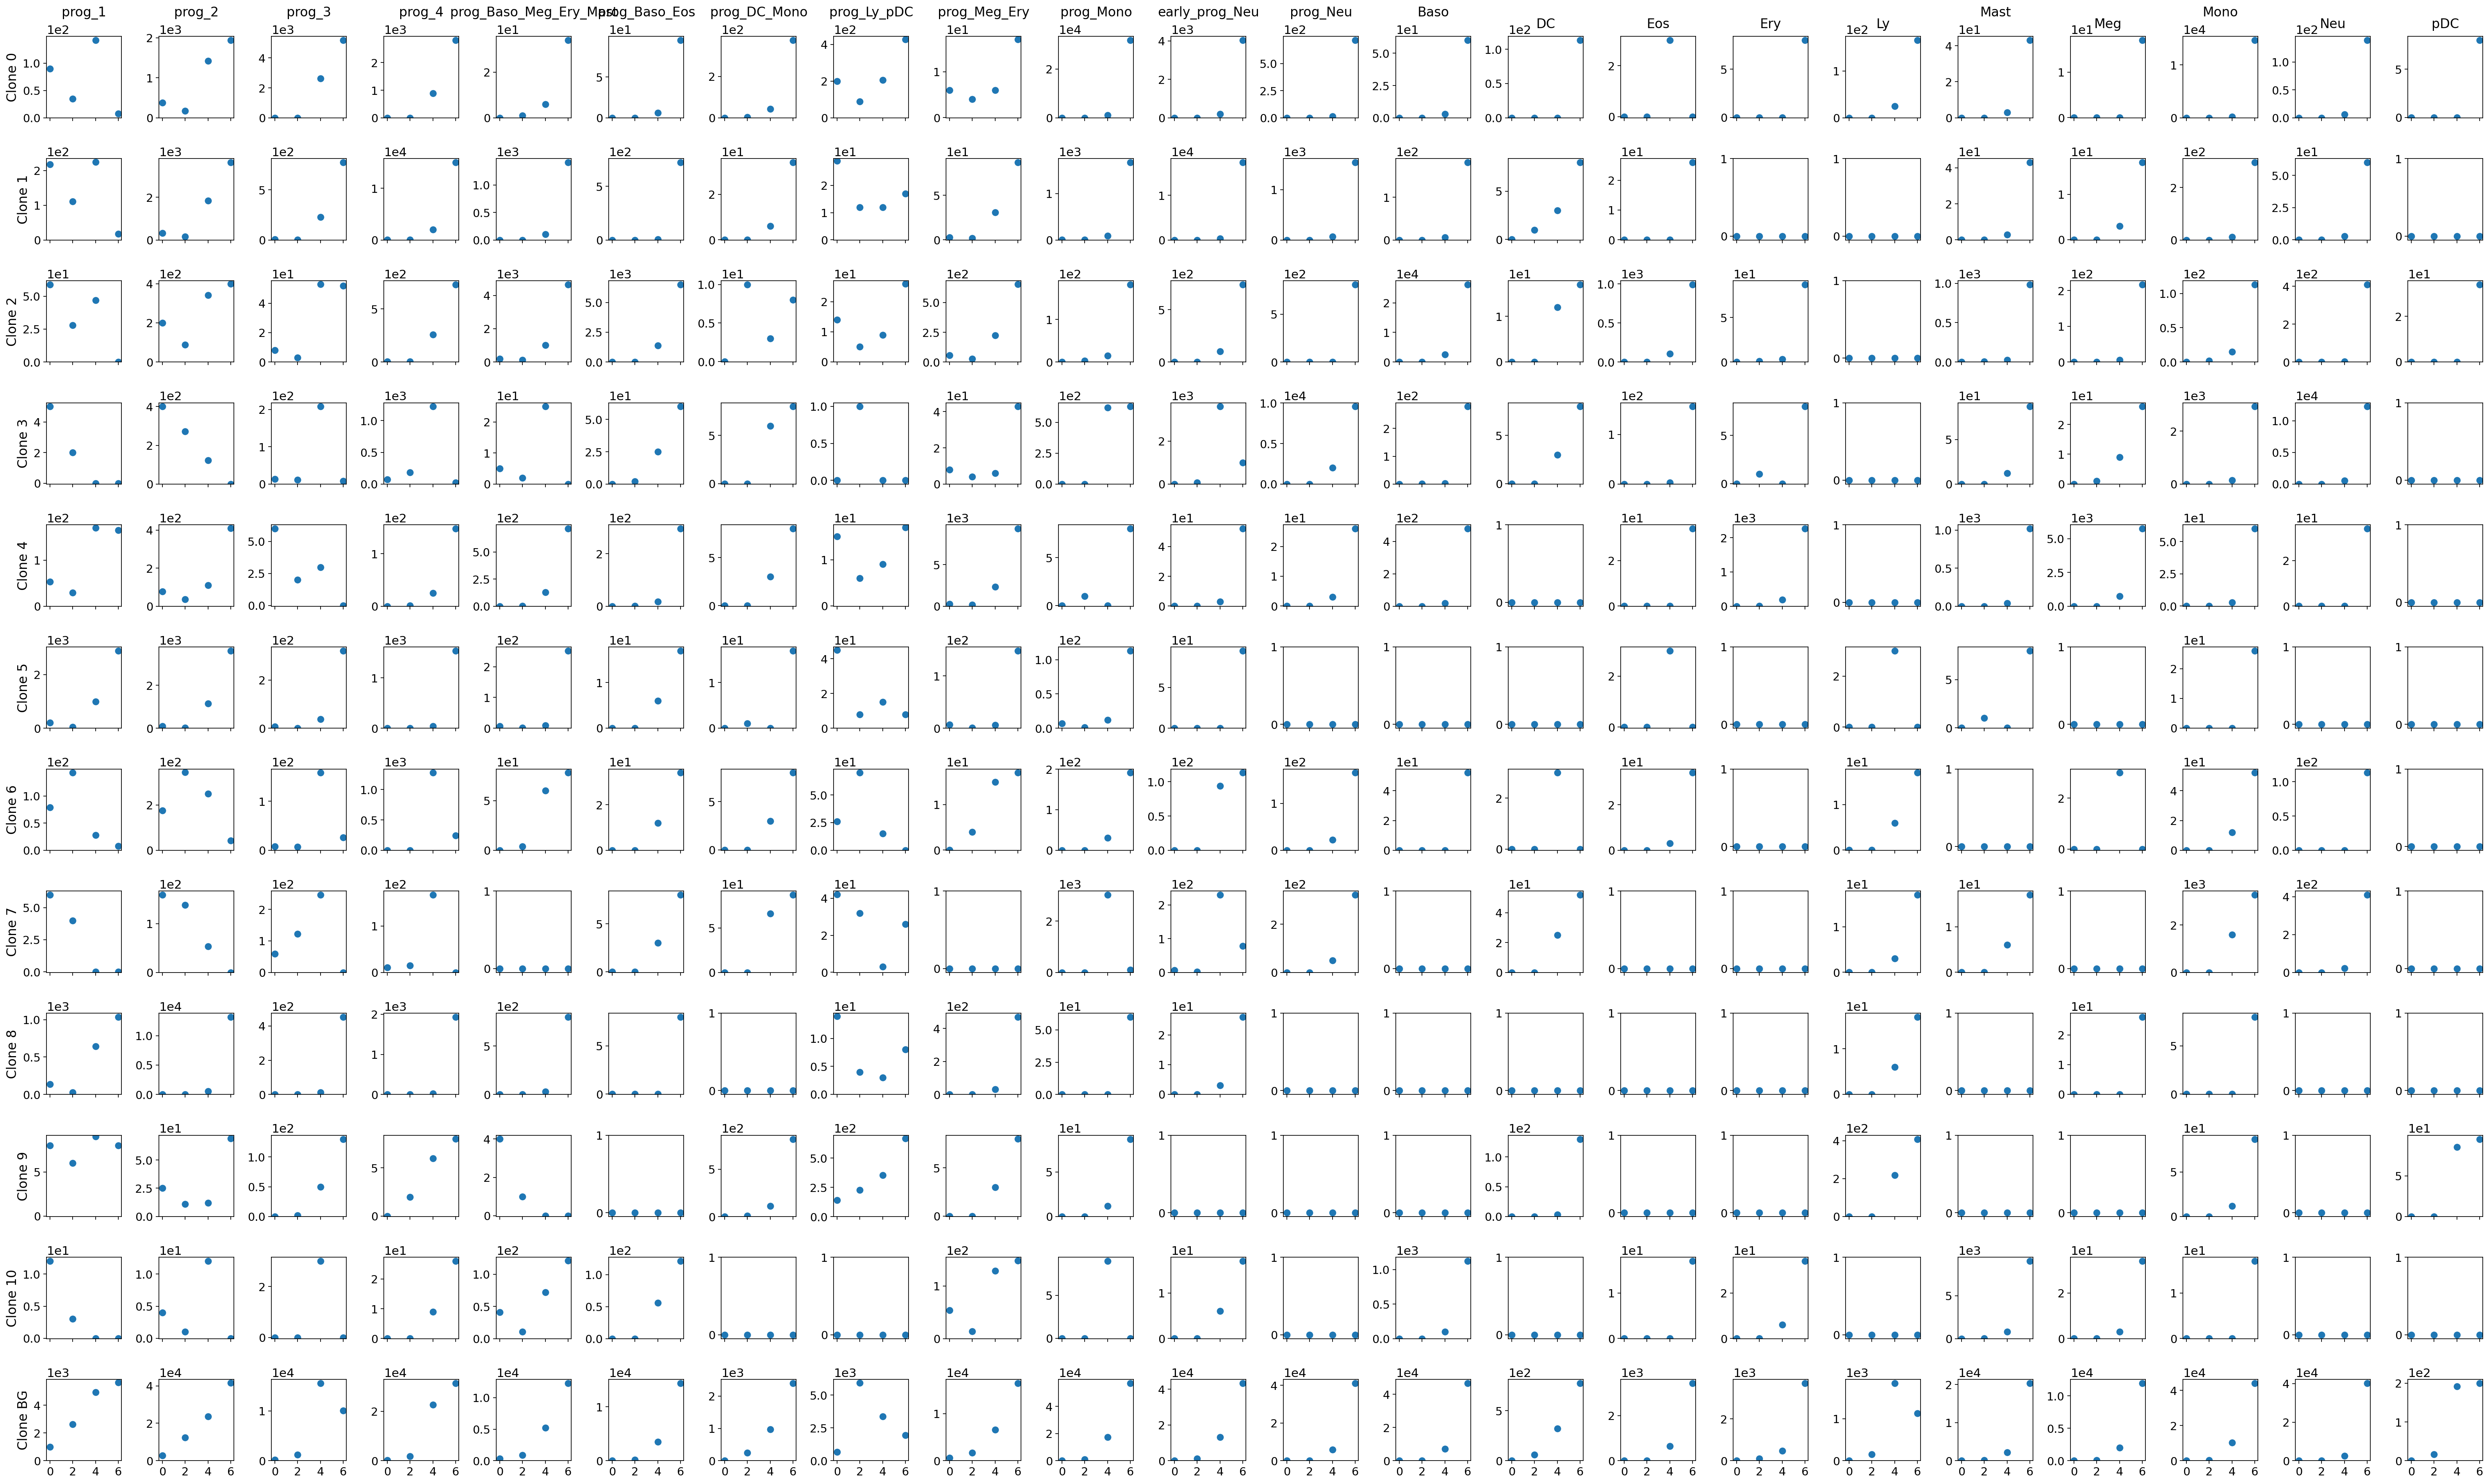

In [155]:
from itertools import product
fig, axes = plt.subplots(kinetics_with_init.shape[1], kinetics_with_init.shape[2], figsize=(50, 30), sharex=True)

anno = pd.read_csv('./annotations.csv')

for row, col in product(range(kinetics_with_init.shape[1]), range(kinetics_with_init.shape[2])):
    axes[row][col].plot(
        [0, 2, 4, 6], 
        kinetics_with_init[:, row, col], 
        marker='o',
        linestyle='',
        markersize=7
    )

    axes[0][col].set_title(anno['populations'][col], fontsize=15, pad=10)
    axes[row][0].set_ylabel(anno['clones'][row], fontsize=15)
    axes[row][col].set_xticks([0, 2, 4, 6])
    axes[row][col].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    axes[row][col].tick_params(axis='both', labelsize=13)
    axes[row][col].grid(visible=False)
    axes[row][col].set_ylim(bottom=-0.05)

    if kinetics_with_init[:, row, col].sum() == 0:
        axes[row][col].set_ylim(-0.05, 1)
        axes[row][col].set_yticks([0, 1])

fig.subplots_adjust(hspace=0.5)
fig.subplots_adjust(wspace=0.5)

In [153]:
adata_day2[adata_day2.obs['meta_clones'] == '9'].obs

,Time_point,Population,Annotation,Well,time_cat,leiden,comb,label_man,clones,meta_clones
14615,2.0,LK,undiff,0,2.0,5,undiff_5,prog_Ly_pDC,Clone_1829,9
15097,2.0,LK,undiff,0,2.0,5,undiff_5,prog_Ly_pDC,Clone_5372,9
18391,2.0,LK,undiff,0,2.0,5,undiff_5,prog_Ly_pDC,Clone_5060,9
18786,2.0,LK,undiff,0,2.0,5,undiff_5,prog_Ly_pDC,Clone_4598,9
43882,2.0,LSK,undiff,0,2.0,5,undiff_5,prog_Ly_pDC,Clone_1617,9
45415,2.0,LSK,undiff,0,2.0,5,undiff_5,prog_Ly_pDC,Clone_2080,9
45888,2.0,LSK,undiff,0,2.0,5,undiff_5,prog_Ly_pDC,Clone_1360,9
46234,2.0,LSK,undiff,0,2.0,5,undiff_5,prog_Ly_pDC,Clone_1617,9
46276,2.0,LSK,undiff,0,2.0,5,undiff_5,prog_Ly_pDC,Clone_1576,9
46463,2.0,LSK,undiff,0,2.0,5,undiff_5,prog_Ly_pDC,Clone_5095,9
